In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
data_path = Path("../Project_Train_Datasets")

file_map = {
    "AMZN": data_path / "AMZN_5levels_train.csv",
    "GOOG": data_path / "GOOG_5levels_train.csv",
    "INTC": data_path / "INTC_5levels_train.csv",
    "MSFT": data_path / "MSFT_5levels_train.csv",
}

In [3]:
def load_and_engineer_stock(path, stock_name):
    df = pd.read_csv(path).copy()

    # ----------------------------
    # Parse timestamp
    # ----------------------------
    df["ts"] = pd.to_datetime(df["Time"], format="%H:%M:%S.%f", errors="coerce")
    df = df.dropna(subset=["ts"]).copy()
    df = df.sort_values("ts").reset_index(drop=True)

    # minute bucket
    df["minute"] = df["ts"].dt.floor("min")

    # seconds within minute
    df["sec_in_min"] = (
        df["ts"].dt.second +
        df["ts"].dt.microsecond / 1_000_000
    )

    # ----------------------------
    # Best bid / best ask / sizes
    # ----------------------------
    df["bid1"] = df["BidPrice_1"]
    df["ask1"] = df["AskPrice_1"]
    df["bsz1"] = df["BidSize_1"]
    df["asz1"] = df["AskSize_1"]

    # recompute mid / spread
    df["mid"] = (df["bid1"] + df["ask1"]) / 2
    df["spread"] = df["ask1"] - df["bid1"]

    # ----------------------------
    # Top-of-book liquidity features
    # ----------------------------
    df["bid_liq_1"] = df["bid1"] * df["bsz1"]
    df["ask_liq_1"] = df["ask1"] * df["asz1"]
    df["depth_value_1"] = df["bid_liq_1"] + df["ask_liq_1"]

    # see which side has more liquidity at top of book
    denom1 = df["bsz1"] + df["asz1"]
    df["imbalance_1"] = np.where(
        denom1 > 0,
        (df["bsz1"] - df["asz1"]) / denom1,
        0.0
    )

    # see which side does price lean towards at top of book
    df["microprice"] = np.where(
        denom1 > 0,
        (df["ask1"] * df["bsz1"] + df["bid1"] * df["asz1"]) / denom1,
        df["mid"]
    )
    df["micro_minus_mid"] = df["microprice"] - df["mid"]

    # ----------------------------
    # Look at 5-level depth features
    # ----------------------------
    bid_size_cols = [f"BidSize_{i}" for i in range(1, 6)]
    ask_size_cols = [f"AskSize_{i}" for i in range(1, 6)]

    df["total_bid_size_5"] = df[bid_size_cols].sum(axis=1)
    df["total_ask_size_5"] = df[ask_size_cols].sum(axis=1)

    total_depth_5 = df["total_bid_size_5"] + df["total_ask_size_5"]
    df["imbalance_5"] = np.where(
        total_depth_5 > 0,
        (df["total_bid_size_5"] - df["total_ask_size_5"]) / total_depth_5,
        0.0
    )

    bid_notional_5 = sum(df[f"BidPrice_{i}"] * df[f"BidSize_{i}"] for i in range(1, 6))
    ask_notional_5 = sum(df[f"AskPrice_{i}"] * df[f"AskSize_{i}"] for i in range(1, 6))

    # Compute weighted average price across 5 levels of the orderbook
    df["wap_bid_5"] = np.where(
        df["total_bid_size_5"] > 0,
        bid_notional_5 / df["total_bid_size_5"],
        df["bid1"]
    )

    df["wap_ask_5"] = np.where(
        df["total_ask_size_5"] > 0,
        ask_notional_5 / df["total_ask_size_5"],
        df["ask1"]
    )

    # ----------------------------
    # Recent changes
    # ----------------------------
    change_cols = [
        "mid", "spread", "imbalance_1", "imbalance_5",
        "micro_minus_mid", "bid_liq_1", "ask_liq_1",
        "total_bid_size_5", "total_ask_size_5"
    ]

    for col in change_cols:
        df[f"{col}_chg1"] = df[col].diff()

    # ----------------------------
    # Position inside minute
    # ----------------------------
    df["event_idx_in_min"] = df.groupby("minute").cumcount()
    df["n_events_in_min"] = df.groupby("minute")["minute"].transform("size")

    df["event_frac_in_min"] = np.where(
        df["n_events_in_min"] > 1,
        df["event_idx_in_min"] / (df["n_events_in_min"] - 1),
        0.0
    )

    # ----------------------------
    # Labels for BUY and SELL
    # ----------------------------
    # Buy regret: how far current ask is above the best future ask in same minute
    df["future_min_ask_in_min"] = (
        df.groupby("minute")["ask1"]
          .transform(lambda s: s.iloc[::-1].cummin().iloc[::-1])
    )
    df["buy_regret"] = df["ask1"] - df["future_min_ask_in_min"]

    # Sell regret: how far current bid is below the best future bid in same minute
    df["future_max_bid_in_min"] = (
        df.groupby("minute")["bid1"]
          .transform(lambda s: s.iloc[::-1].cummax().iloc[::-1])
    )
    df["sell_regret"] = df["future_max_bid_in_min"] - df["bid1"]

    df["stock"] = stock_name

    return df

In [4]:
all_dfs = []

for stock, path in file_map.items():
    df_stock = load_and_engineer_stock(path, stock)
    all_dfs.append(df_stock)

full_df = pd.concat(all_dfs, ignore_index=True)

print(full_df.shape)
full_df.head()

(1149529, 70)


,Time,BidPrice_5,BidPrice_4,BidPrice_3,BidPrice_2,BidPrice_1,BidSize_5,BidSize_4,BidSize_3,BidSize_2,...,total_bid_size_5_chg1,total_ask_size_5_chg1,event_idx_in_min,n_events_in_min,event_frac_in_min,future_min_ask_in_min,buy_regret,future_max_bid_in_min,sell_regret,stock
0,09:30:00.017,222.62,223.0,223.04,223.07,223.18,100,10,100,200,...,NaN,NaN,0,722,0.000000,223.86,0.09,224.29,1.11,AMZN
1,09:30:00.189,223.50,223.6,223.65,223.75,223.81,100,15,2,100,...,-272.0,624.0,1,722,0.001387,223.86,0.09,224.29,0.48,AMZN
2,09:30:00.189,223.50,223.6,223.65,223.75,223.81,100,15,2,100,...,0.0,0.0,2,722,0.002774,223.86,0.09,224.29,0.48,AMZN
3,09:30:00.189,223.50,223.6,223.65,223.75,223.81,100,15,2,100,...,0.0,0.0,3,722,0.004161,223.86,0.09,224.29,0.48,AMZN
4,09:30:00.189,223.50,223.6,223.65,223.75,223.81,100,15,2,100,...,0.0,0.0,4,722,0.005548,223.86,0.09,224.29,0.48,AMZN


In [5]:
feature_cols = [
    "bid1",
    "ask1",
    "mid",
    "spread",
    "bsz1",
    "asz1",
    "bid_liq_1",
    "ask_liq_1",
    "depth_value_1",
    "imbalance_1",
    "microprice",
    "micro_minus_mid",
    "total_bid_size_5",
    "total_ask_size_5",
    "imbalance_5",
    "wap_bid_5",
    "wap_ask_5",
    "mid_chg1",
    "spread_chg1",
    "imbalance_1_chg1",
    "imbalance_5_chg1",
    "micro_minus_mid_chg1",
    "bid_liq_1_chg1",
    "ask_liq_1_chg1",
    "total_bid_size_5_chg1",
    "total_ask_size_5_chg1",
    "sec_in_min",
    "event_idx_in_min",
    "n_events_in_min",
    "event_frac_in_min",
]

In [6]:
model_df = full_df.copy()

# converts inf/-inf to NaN so we can drop them later
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# fill diff features with 0
for col in feature_cols:
    if col.endswith("_chg1"):
        model_df[col] = model_df[col].fillna(0)

required_cols = feature_cols + [
    "buy_regret",
    "sell_regret",
    "minute",
    "stock",
    "ts",
    "ask1",
    "bid1"
]

model_df = model_df.dropna(subset=required_cols).copy()

print(model_df.shape)

(1149529, 70)


In [7]:
# add stock dummies, except one to avoid collinearity
model_df = pd.get_dummies(model_df, columns=["stock"], drop_first=True)

stock_dummy_cols = [c for c in model_df.columns if c.startswith("stock_")]
all_feature_cols = feature_cols + stock_dummy_cols

print("Added stock dummies:", stock_dummy_cols)

Added stock dummies: ['stock_GOOG', 'stock_INTC', 'stock_MSFT']


In [8]:
# 7/3 split
unique_minutes = np.array(sorted(model_df["minute"].unique()))
split_idx = int(len(unique_minutes) * 0.7)

train_minutes = set(unique_minutes[:split_idx])
test_minutes = set(unique_minutes[split_idx:])

train_df = model_df[model_df["minute"].isin(train_minutes)].copy()
test_df  = model_df[model_df["minute"].isin(test_minutes)].copy()

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))
print("Train minutes:", len(train_minutes))
print("Test minutes :", len(test_minutes))

Train rows: 883579
Test rows : 265950
Train minutes: 189
Test minutes : 81


We train regression models to estimate the opportunity cost of executing at a given timestamp within the minute. The buy model predicts how much worse the current ask is relative to the best later ask in the minute, and the sell model predicts how much worse the current bid is relative to the best later bid. We then execute at the timestamp with the lowest predicted regret.

In [9]:
X_train = train_df[all_feature_cols]
X_test  = test_df[all_feature_cols]

y_train_buy = train_df["buy_regret"]
y_test_buy  = test_df["buy_regret"]

y_train_sell = train_df["sell_regret"]
y_test_sell  = test_df["sell_regret"]

buy_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

sell_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

buy_model.fit(X_train, y_train_buy)
sell_model.fit(X_train, y_train_sell)

train_buy_pred = buy_model.predict(X_train)
test_buy_pred  = buy_model.predict(X_test)

train_sell_pred = sell_model.predict(X_train)
test_sell_pred  = sell_model.predict(X_test)

print("BUY MODEL")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train_buy, train_buy_pred)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test_buy, test_buy_pred)))
print("Train R^2 :", r2_score(y_train_buy, train_buy_pred))
print("Test R^2  :", r2_score(y_test_buy, test_buy_pred))

print("\nSELL MODEL")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train_sell, train_sell_pred)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test_sell, test_sell_pred)))
print("Train R^2 :", r2_score(y_train_sell, train_sell_pred))
print("Test R^2  :", r2_score(y_test_sell, test_sell_pred))

BUY MODEL
Train RMSE: 0.07965577554924082
Test RMSE : 0.04905529017200229
Train R^2 : 0.45670996122629504
Test R^2  : 0.3591456917010031

SELL MODEL
Train RMSE: 0.06651150343707249
Test RMSE : 0.04781916548157094
Train R^2 : 0.3664867034306851
Test R^2  : 0.4072609261101392


In [10]:
# Time-based Threshold
X_train = train_df[all_feature_cols].copy()

train_df = train_df.copy()
train_df["pred_buy_regret"] = buy_model.predict(X_train)
train_df["pred_sell_regret"] = sell_model.predict(X_train)

buy_threshold = train_df["pred_buy_regret"].quantile(0.2)
sell_threshold = train_df["pred_sell_regret"].quantile(0.2)

In [11]:
test_df = test_df.copy()
test_df["pred_buy_regret"] = test_buy_pred
test_df["pred_sell_regret"] = test_sell_pred

In [12]:
def recover_stock_name(df):
    df = df.copy()

    df["stock_name"] = "AMZN"  # default if all dummies are zero

    if "stock_GOOG" in df.columns:
        df.loc[df["stock_GOOG"] == 1, "stock_name"] = "GOOG"
    if "stock_INTC" in df.columns:
        df.loc[df["stock_INTC"] == 1, "stock_name"] = "INTC"
    if "stock_MSFT" in df.columns:
        df.loc[df["stock_MSFT"] == 1, "stock_name"] = "MSFT"

    return df

test_df = recover_stock_name(test_df)
train_df = recover_stock_name(train_df)

In [13]:
def pick_buy_model_trades_threshold(df, buy_threshold, fallback_last=True):
    """
    No-look-ahead buy execution.
    
    For each stock_name x minute:
    - sort rows by timestamp
    - execute immediately at the FIRST row where pred_buy_regret <= buy_threshold
    - if no row triggers and fallback_last=True, buy at the final row of the minute
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
        stock_name, minute, ts, ask1, pred_buy_regret
    buy_threshold : float
        Trigger threshold for predicted buy regret
    fallback_last : bool
        If True, force a buy at the last row of the minute when no trigger occurs
    
    Returns
    -------
    pd.DataFrame
    """
    trades = []

    grouped = df.sort_values(["stock_name", "minute", "ts"]).groupby(
        ["stock_name", "minute"], sort=False
    )

    for (stock, minute), g in grouped:
        g = g.reset_index(drop=True)

        # first timestamp where model says "buy now"
        trigger = g[g["pred_buy_regret"] <= buy_threshold]

        if len(trigger) > 0:
            row = trigger.iloc[0]
            trigger_type = "threshold_hit"
        elif fallback_last:
            row = g.iloc[-1]
            trigger_type = "fallback_last"
        else:
            continue

        trades.append({
            "stock_name": stock,
            "minute": minute,
            "buy_time": row["ts"],
            "buy_price": row["ask1"],
            "pred_buy_regret": row["pred_buy_regret"],
            "trigger_type": trigger_type,
            "strategy": "Model_Buy_Threshold"
        })

    return pd.DataFrame(trades).sort_values(["stock_name", "minute"]).reset_index(drop=True)


def pick_sell_model_trades_threshold(df, sell_threshold, fallback_last=True):
    """
    No-look-ahead sell execution.
    
    For each stock_name x minute:
    - sort rows by timestamp
    - execute immediately at the FIRST row where pred_sell_regret <= sell_threshold
    - if no row triggers and fallback_last=True, sell at the final row of the minute
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
        stock_name, minute, ts, bid1, pred_sell_regret
    sell_threshold : float
        Trigger threshold for predicted sell regret
    fallback_last : bool
        If True, force a sell at the last row of the minute when no trigger occurs
    
    Returns
    -------
    pd.DataFrame
    """
    trades = []

    grouped = df.sort_values(["stock_name", "minute", "ts"]).groupby(
        ["stock_name", "minute"], sort=False
    )

    for (stock, minute), g in grouped:
        g = g.reset_index(drop=True)

        # first timestamp where model says "sell now"
        trigger = g[g["pred_sell_regret"] <= sell_threshold]

        if len(trigger) > 0:
            row = trigger.iloc[0]
            trigger_type = "threshold_hit"
        elif fallback_last:
            row = g.iloc[-1]
            trigger_type = "fallback_last"
        else:
            continue

        trades.append({
            "stock_name": stock,
            "minute": minute,
            "sell_time": row["ts"],
            "sell_price": row["bid1"],
            "pred_sell_regret": row["pred_sell_regret"],
            "trigger_type": trigger_type,
            "strategy": "Model_Sell_Threshold"
        })

    return pd.DataFrame(trades).sort_values(["stock_name", "minute"]).reset_index(drop=True)

In [14]:
def pick_twap_buy_trades(df):
    idx = df.groupby(["stock_name", "minute"])["ts"].idxmin()
    out = df.loc[idx, ["stock_name", "minute", "ts", "ask1"]].copy()
    out = out.rename(columns={
        "ts": "buy_time",
        "ask1": "buy_price"
    })
    out["strategy"] = "TWAP_Buy"
    return out.sort_values(["stock_name", "minute"]).reset_index(drop=True)

def pick_twap_sell_trades(df):
    idx = df.groupby(["stock_name", "minute"])["ts"].idxmin()
    out = df.loc[idx, ["stock_name", "minute", "ts", "bid1"]].copy()
    out = out.rename(columns={
        "ts": "sell_time",
        "bid1": "sell_price"
    })
    out["strategy"] = "TWAP_Sell"
    return out.sort_values(["stock_name", "minute"]).reset_index(drop=True)

In [15]:
# pick the actual best buy/sell price within each minute as oracle benchmark
def pick_oracle_best_buy(df):
    idx = df.groupby(["stock_name", "minute"])["ask1"].idxmin()
    out = df.loc[idx, ["stock_name", "minute", "ts", "ask1"]].copy()
    out = out.rename(columns={
        "ts": "oracle_buy_time",
        "ask1": "oracle_buy_price"
    })
    return out.sort_values(["stock_name", "minute"]).reset_index(drop=True)

def pick_oracle_best_sell(df):
    idx = df.groupby(["stock_name", "minute"])["bid1"].idxmax()
    out = df.loc[idx, ["stock_name", "minute", "ts", "bid1"]].copy()
    out = out.rename(columns={
        "ts": "oracle_sell_time",
        "bid1": "oracle_sell_price"
    })
    return out.sort_values(["stock_name", "minute"]).reset_index(drop=True)

In [16]:
model_buy = pick_buy_model_trades_threshold(test_df, buy_threshold, fallback_last=True)
model_sell = pick_sell_model_trades_threshold(test_df, sell_threshold, fallback_last=True)

twap_buy = pick_twap_buy_trades(test_df)
twap_sell = pick_twap_sell_trades(test_df)

oracle_buy = pick_oracle_best_buy(test_df)
oracle_sell = pick_oracle_best_sell(test_df)

print(model_buy.head())
print(model_sell.head())

  stock_name              minute                buy_time  buy_price  \
0       AMZN 1900-01-01 12:39:00 1900-01-01 12:39:59.729     222.54   
1       AMZN 1900-01-01 12:40:00 1900-01-01 12:40:59.978     222.54   
2       AMZN 1900-01-01 12:41:00 1900-01-01 12:41:53.210     222.43   
3       AMZN 1900-01-01 12:42:00 1900-01-01 12:42:59.627     222.65   
4       AMZN 1900-01-01 12:43:00 1900-01-01 12:43:54.278     222.57   

   pred_buy_regret   trigger_type             strategy  
0         0.039410  fallback_last  Model_Buy_Threshold  
1         0.056131  fallback_last  Model_Buy_Threshold  
2        -0.023862  threshold_hit  Model_Buy_Threshold  
3         0.039795  fallback_last  Model_Buy_Threshold  
4        -0.033526  threshold_hit  Model_Buy_Threshold  
  stock_name              minute               sell_time  sell_price  \
0       AMZN 1900-01-01 12:39:00 1900-01-01 12:39:59.729      222.39   
1       AMZN 1900-01-01 12:40:00 1900-01-01 12:40:59.978      222.36   
2       AMZN 19

In [17]:
model_buy_cmp = model_buy.rename(columns={
    "buy_time": "model_buy_time",
    "buy_price": "model_buy_price"
})

twap_buy_cmp = twap_buy.rename(columns={
    "buy_time": "twap_buy_time",
    "buy_price": "twap_buy_price"
})

buy_compare = (
    model_buy_cmp
    .merge(twap_buy_cmp, on=["stock_name", "minute"], how="inner")
    .merge(oracle_buy, on=["stock_name", "minute"], how="inner")
)

buy_compare["improvement_vs_twap"] = (
    buy_compare["twap_buy_price"] - buy_compare["model_buy_price"]
)

buy_compare["oracle_gap"] = (
    buy_compare["model_buy_price"] - buy_compare["oracle_buy_price"]
)

In [18]:
model_sell_cmp = model_sell.rename(columns={
    "sell_time": "model_sell_time",
    "sell_price": "model_sell_price"
})

twap_sell_cmp = twap_sell.rename(columns={
    "sell_time": "twap_sell_time",
    "sell_price": "twap_sell_price"
})

sell_compare = (
    model_sell_cmp
    .merge(twap_sell_cmp, on=["stock_name", "minute"], how="inner")
    .merge(oracle_sell, on=["stock_name", "minute"], how="inner")
)

sell_compare["improvement_vs_twap"] = (
    sell_compare["model_sell_price"] - sell_compare["twap_sell_price"]
)

sell_compare["oracle_gap"] = (
    sell_compare["oracle_sell_price"] - sell_compare["model_sell_price"]
)

In [19]:
buy_summary = (
    buy_compare.groupby("stock_name")
    .agg(
        avg_model_buy=("model_buy_price", "mean"),
        avg_twap_buy=("twap_buy_price", "mean"),
        avg_oracle_buy=("oracle_buy_price", "mean"),
        avg_improvement_vs_twap=("improvement_vs_twap", "mean"),
        avg_oracle_gap=("oracle_gap", "mean"),
        threshold_hits=("trigger_type", lambda x: (x == "threshold_hit").sum()),
        fallbacks=("trigger_type", lambda x: (x == "fallback_last").sum()),
        n_minutes=("minute", "count")
    )
    .reset_index()
)

sell_summary = (
    sell_compare.groupby("stock_name")
    .agg(
        avg_model_sell=("model_sell_price", "mean"),
        avg_twap_sell=("twap_sell_price", "mean"),
        avg_oracle_sell=("oracle_sell_price", "mean"),
        avg_improvement_vs_twap=("improvement_vs_twap", "mean"),
        avg_oracle_gap=("oracle_gap", "mean"),
        threshold_hits=("trigger_type", lambda x: (x == "threshold_hit").sum()),
        fallbacks=("trigger_type", lambda x: (x == "fallback_last").sum()),
        n_minutes=("minute", "count")
    )
    .reset_index()
)

In [20]:
overall_buy = {
    "avg_model_buy": buy_compare["model_buy_price"].mean(),
    "avg_twap_buy": buy_compare["twap_buy_price"].mean(),
    "avg_oracle_buy": buy_compare["oracle_buy_price"].mean(),
    "avg_improvement_vs_twap": buy_compare["improvement_vs_twap"].mean(),
    "avg_oracle_gap": buy_compare["oracle_gap"].mean(),
    "threshold_hit_rate": (buy_compare["trigger_type"] == "threshold_hit").mean()
}

overall_sell = {
    "avg_model_sell": sell_compare["model_sell_price"].mean(),
    "avg_twap_sell": sell_compare["twap_sell_price"].mean(),
    "avg_oracle_sell": sell_compare["oracle_sell_price"].mean(),
    "avg_improvement_vs_twap": sell_compare["improvement_vs_twap"].mean(),
    "avg_oracle_gap": sell_compare["oracle_gap"].mean(),
    "threshold_hit_rate": (sell_compare["trigger_type"] == "threshold_hit").mean()
}

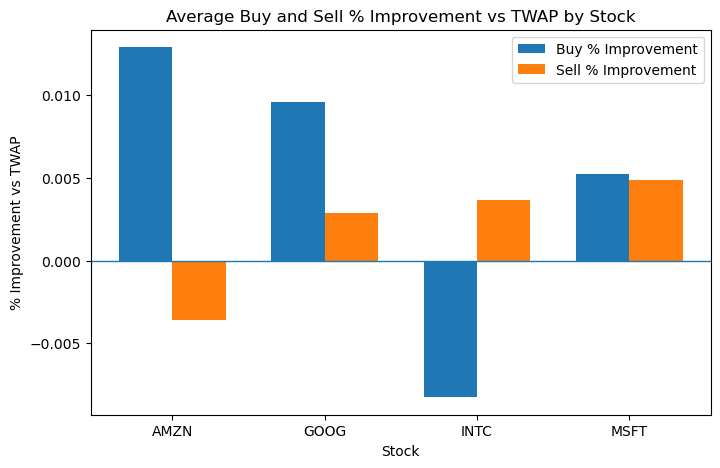

In [22]:
# percentage improvement vs TWAP
buy_compare["pct_improvement_vs_twap"] = (
    (buy_compare["twap_buy_price"] - buy_compare["model_buy_price"])
    / buy_compare["twap_buy_price"]
) * 100

sell_compare["pct_improvement_vs_twap"] = (
    (sell_compare["model_sell_price"] - sell_compare["twap_sell_price"])
    / sell_compare["twap_sell_price"]
) * 100

# average by stock
buy_pct_summary = (
    buy_compare.groupby("stock_name")["pct_improvement_vs_twap"]
    .mean()
    .reset_index(name="buy_pct_improvement")
)

sell_pct_summary = (
    sell_compare.groupby("stock_name")["pct_improvement_vs_twap"]
    .mean()
    .reset_index(name="sell_pct_improvement")
)

# merge for plotting
pct_plot_df = buy_pct_summary.merge(sell_pct_summary, on="stock_name", how="outer").fillna(0)

# plot
x = np.arange(len(pct_plot_df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pct_plot_df["buy_pct_improvement"], width, label="Buy % Improvement")
plt.bar(x + width/2, pct_plot_df["sell_pct_improvement"], width, label="Sell % Improvement")

plt.axhline(0, linewidth=1)
plt.xticks(x, pct_plot_df["stock_name"])
plt.xlabel("Stock")
plt.ylabel("% Improvement vs TWAP")
plt.title("Average Buy and Sell % Improvement vs TWAP by Stock")
plt.legend()
plt.show()

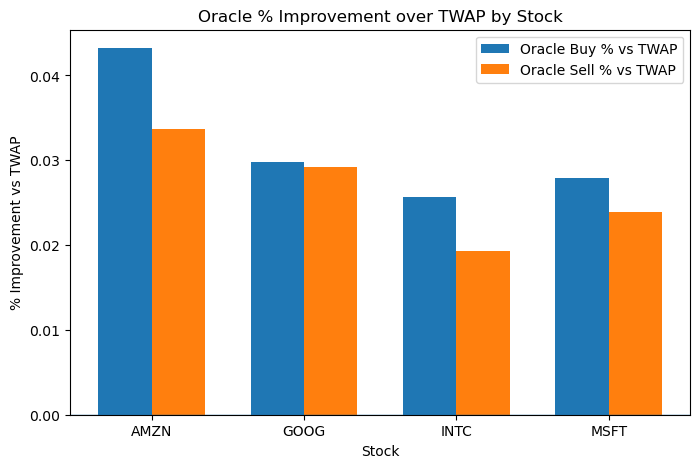

In [23]:
# percentage improvement of oracle over TWAP
buy_compare["oracle_pct_vs_twap"] = (
    (buy_compare["twap_buy_price"] - buy_compare["oracle_buy_price"])
    / buy_compare["twap_buy_price"]
) * 100

sell_compare["oracle_pct_vs_twap"] = (
    (sell_compare["oracle_sell_price"] - sell_compare["twap_sell_price"])
    / sell_compare["twap_sell_price"]
) * 100

# average by stock
oracle_buy_pct_summary = (
    buy_compare.groupby("stock_name")["oracle_pct_vs_twap"]
    .mean()
    .reset_index(name="oracle_buy_pct")
)

oracle_sell_pct_summary = (
    sell_compare.groupby("stock_name")["oracle_pct_vs_twap"]
    .mean()
    .reset_index(name="oracle_sell_pct")
)

# merge for plotting
oracle_pct_plot_df = (
    oracle_buy_pct_summary
    .merge(oracle_sell_pct_summary, on="stock_name", how="outer")
    .fillna(0)
)

# plot
x = np.arange(len(oracle_pct_plot_df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, oracle_pct_plot_df["oracle_buy_pct"], width, label="Oracle Buy % vs TWAP")
plt.bar(x + width/2, oracle_pct_plot_df["oracle_sell_pct"], width, label="Oracle Sell % vs TWAP")

plt.axhline(0, linewidth=1)
plt.xticks(x, oracle_pct_plot_df["stock_name"])
plt.xlabel("Stock")
plt.ylabel("% Improvement vs TWAP")
plt.title("Oracle % Improvement over TWAP by Stock")
plt.legend()
plt.show()

In [24]:
# Compute arithematic mean
multi_factor_buy_mean = (
    buy_compare.assign(
        improvement=buy_compare["twap_buy_price"] - buy_compare["model_buy_price"]
    )
    .groupby("stock_name", as_index=False)["improvement"]
    .mean()
    .rename(columns={
        "stock_name": "stock",
        "improvement": "average_improvement"
    })
)

multi_factor_sell_mean = (
    sell_compare.assign(
        improvement=sell_compare["model_sell_price"] - sell_compare["twap_sell_price"]
    )
    .groupby("stock_name", as_index=False)["improvement"]
    .mean()
    .rename(columns={
        "stock_name": "stock",
        "improvement": "average_improvement"
    })
)

In [25]:
multi_factor_buy_mean.to_csv("../backtest/strategy4_buy_execution.csv", index=False)
multi_factor_sell_mean.to_csv("../backtest/strategy4_sell_execution.csv", index=False)